In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Contextualização**
A Big Mart buscava entender quais fatores influenciam o volume de vendas de seus
produtos (`OutletSales`) nas diferentes lojas da rede. O objetivo deste projeto é
construir um modelo preditivo capaz de estimar essas vendas, permitindo que a empresa
se organize melhor em termos de estoque e estratégia comercial.


In [56]:
df = pd.read_csv('Train-Set.csv')
df.head()

,ProductID,Weight,FatContent,ProductVisibility,ProductType,MRP,OutletID,EstablishmentYear,OutletSize,LocationType,OutletType,OutletSales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [57]:
## Retorna dimensão da tabela (linhas/colunas):
df.shape

(8523, 12)

In [58]:
## Soma espaços vazios em cada coluna:
df.isnull().sum()

,0
ProductID,0
Weight,1463
FatContent,0
ProductVisibility,0
ProductType,0
MRP,0
OutletID,0
EstablishmentYear,0
OutletSize,2410
LocationType,0


**Preparação dos Dados:**
Durante a análise inicial, identifiquei os seguintes problemas nos dados:

- **FatContent**: a coluna apresentava redundância de grafias para os mesmos valores
(ex: "Low Fat", "LF", "low fat"). Padronizei todas as variações para garantir
consistência e uma melhor leitura dos dados pelo modelo.

- **OutletSize**: faltavam aproximadamente 28% dos valores, concentrados majoritariamente
em lojas do tipo Grocery Store e Supermarket Type1. Em vez de preencher com a moda geral,
usei a moda *dentro de cada tipo de loja* (OutletType), o que gera uma estimativa mais
fiel à realidade de cada grupo.

- **Weight**: faltavam cerca de 17% dos valores. Como o mesmo produto (ProductID)
aparece em várias lojas, preenchi os valores faltando com a média de peso do mesmo
produto em outras lojas, e usei a média geral apenas como último recurso para os
casos remanescentes.

In [59]:
## Conta quantas vezes aparece valores em FatContent:
df['FatContent'].value_counts()

,count
FatContent,
Low Fat,5089
Regular,2889
LF,316
reg,117
low fat,112


In [60]:
## Agrupar por tipo de loja e soma dos nulos:
df.groupby('OutletType')['OutletSize'].apply(lambda x: x.isnull().sum())

,OutletSize
OutletType,
Grocery Store,555
Supermarket Type1,1855
Supermarket Type2,0
Supermarket Type3,0


In [61]:
## Padronizar o FatContent:
df['FatContent'] = df['FatContent'].replace({
    'low fat': 'Low Fat',
    'LF': 'Low Fat',
    'reg': 'Regular'
})

df['FatContent'].value_counts()

,count
FatContent,
Low Fat,5517
Regular,3006


In [62]:
## Preencher OutletSize pela moda do grupo:
df['OutletSize'] = df.groupby('OutletType')['OutletSize'].transform(
    lambda x: x.fillna(x.mode()[0]) if not x.mode().empty else x
)

df['OutletSize'].isnull().sum()

np.int64(0)

In [63]:
## Preencher Weight pela média do produto:
df['Weight'] = df.groupby('ProductID')['Weight'].transform(
    lambda x: x.fillna(x.mean())
)
df['Weight'] = df['Weight'].fillna(df['Weight'].mean())

df['Weight'].isnull().sum()

np.int64(0)

**EDA:**
Principais descobertas:

- A distribuição de `OutletSales` é assimétrica à direita: a maioria dos produtos
vende pouco, enquanto poucos produtos concentram vendas muito altas.

- Lojas do tipo **Grocery Store** vendem significativamente menos que os demais tipos,
enquanto **Supermarket Type3** lidera em volume de vendas.

- Entre as variáveis numéricas, **MRP** (preço do produto) apresentou a correlação
mais forte com as vendas (0.57), sendo o preditor mais relevante identificado no EDA.

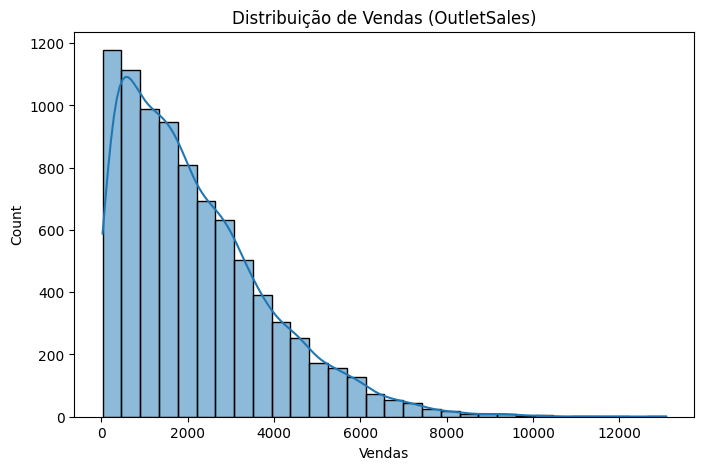

In [64]:
## Distribuição das vendas:
plt.figure(figsize=(8,5))
sns.histplot(df['OutletSales'], bins=30, kde=True)
plt.title('Distribuição de Vendas (OutletSales)')
plt.xlabel('Vendas')
plt.show()

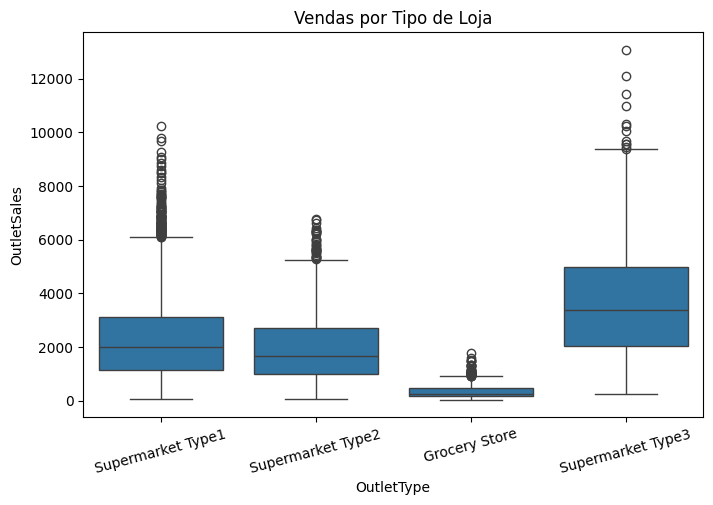

In [65]:
## Vendas por tipo de loja:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='OutletType', y='OutletSales')
plt.title('Vendas por Tipo de Loja')
plt.xticks(rotation=15)
plt.show()

**Feature Engineering:**
Criei duas novas variáveis a partir dos dados originais:

- **OutletAge**: idade da loja, calculada a partir do ano de fundação. Essa variável
é mais interpretável para o modelo do que o ano bruto.

- **ItemCategory**: categoria do produto extraída do prefixo do `ProductID`
(FD = Food, DR = Drinks, NC = Non-Consumable), permitindo capturar padrões por
categoria mesmo sem usar a coluna de texto completa.

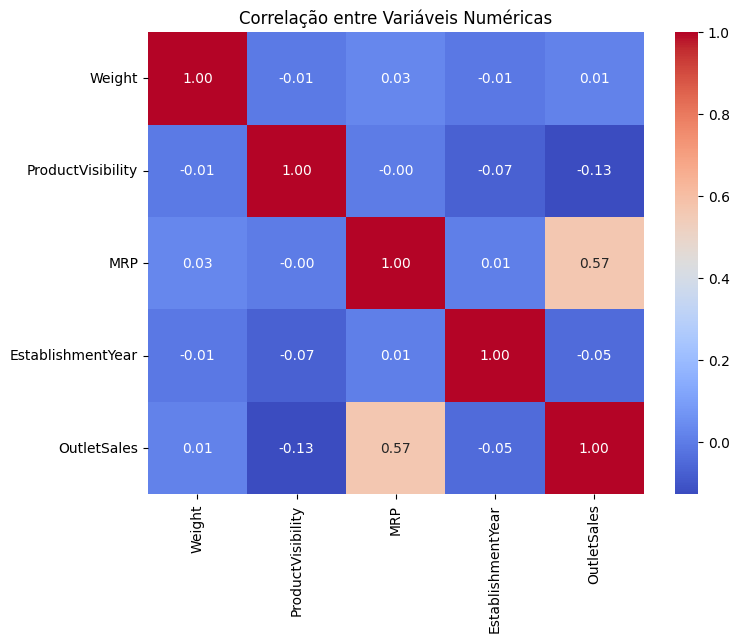

In [66]:
## Correlação entre variáveis numéricas:
plt.figure(figsize=(8,6))
numeric_cols = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlação entre Variáveis Numéricas')
plt.show()

In [67]:
## Descobrir quantos anos a loja tem:
df['OutletAge'] = 2026 - df['EstablishmentYear']
df[['EstablishmentYear', 'OutletAge']].head()

,EstablishmentYear,OutletAge
0,1999,27
1,2009,17
2,1999,27
3,1998,28
4,1987,39


In [68]:
## Extrair a categoria do produto por um ID:
df['ItemCategory'] = df['ProductID'].apply(lambda x: x[:2])
df['ItemCategory'].value_counts()

,count
ItemCategory,
FD,6125
NC,1599
DR,799


**Modelagem:**
Testei dois algoritmos de regressão: **Regressão Linear** e **Random Forest**.

| Métrica | Regressão Linear | Random Forest |
|---|---|---|
| RMSE | 1068.84 | 1095.09 |
| MAE | 792.03 | 765.94 |
| R² | 0.5797 | 0.5588 |

Optei pela **Regressão Linear** como modelo final, pois apresentou R² e RMSE
levemente melhores que o Random Forest. O Random Forest teve vantagem apenas no MAE.
Acredito que o desempenho parecido entre os modelos se deve ao fato de a relação mais
forte identificada no EDA (MRP x OutletSales) já ser predominantemente linear, o que
reduz a vantagem de um modelo não-linear como o Random Forest neste caso.

In [69]:
## Label Encoding (mapear manualmente cada categoria pra um número)
size_map = {'Small': 0, 'Medium': 1, 'High': 2}
df['OutletSize'] = df['OutletSize'].map(size_map)

location_map = {'Tier 1': 0, 'Tier 2': 1, 'Tier 3': 2}
df['LocationType'] = df['LocationType'].map(location_map)

fat_map = {'Low Fat': 0, 'Regular': 1}
df['FatContent'] = df['FatContent'].map(fat_map)

df.head()

,ProductID,Weight,FatContent,ProductVisibility,ProductType,MRP,OutletID,EstablishmentYear,OutletSize,LocationType,OutletType,OutletSales,OutletAge,ItemCategory
0,FDA15,9.30,0,0.016047,Dairy,249.8092,OUT049,1999,1,0,Supermarket Type1,3735.1380,27,FD
1,DRC01,5.92,1,0.019278,Soft Drinks,48.2692,OUT018,2009,1,2,Supermarket Type2,443.4228,17,DR
2,FDN15,17.50,0,0.016760,Meat,141.6180,OUT049,1999,1,0,Supermarket Type1,2097.2700,27,FD
3,FDX07,19.20,1,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,0,2,Grocery Store,732.3800,28,FD
4,NCD19,8.93,0,0.000000,Household,53.8614,OUT013,1987,2,2,Supermarket Type1,994.7052,39,NC


In [70]:
## One-Hot (criar colunas novas com valores true/false)
df = pd.get_dummies(df, columns=['OutletType', 'ItemCategory'], drop_first=True)
df.head()

,ProductID,Weight,FatContent,ProductVisibility,ProductType,MRP,OutletID,EstablishmentYear,OutletSize,LocationType,OutletSales,OutletAge,OutletType_Supermarket Type1,OutletType_Supermarket Type2,OutletType_Supermarket Type3,ItemCategory_FD,ItemCategory_NC
0,FDA15,9.30,0,0.016047,Dairy,249.8092,OUT049,1999,1,0,3735.1380,27,True,False,False,True,False
1,DRC01,5.92,1,0.019278,Soft Drinks,48.2692,OUT018,2009,1,2,443.4228,17,False,True,False,False,False
2,FDN15,17.50,0,0.016760,Meat,141.6180,OUT049,1999,1,0,2097.2700,27,True,False,False,True,False
3,FDX07,19.20,1,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,0,2,732.3800,28,False,False,False,True,False
4,NCD19,8.93,0,0.000000,Household,53.8614,OUT013,1987,2,2,994.7052,39,True,False,False,False,True


In [71]:
df.dtypes

,0
ProductID,object
Weight,float64
FatContent,int64
ProductVisibility,float64
ProductType,object
MRP,float64
OutletID,object
EstablishmentYear,int64
OutletSize,int64
LocationType,int64


In [74]:
## Remover colunas desnecessárias:
df_model = df.drop(columns=['ProductID', 'OutletID', 'EstablishmentYear', 'ProductType'])
df_model.head()

X = df_model.drop(columns=['OutletSales'])
y = df_model['OutletSales']

In [75]:
## Separar features e Target (X são todas as colunas que o modelo usa pra prever / y é a coluna vendas)
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_val.shape)

(6818, 12) (1705, 12)


In [76]:
## Regressão Linear
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

lr = LinearRegression()
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_val)

rmse_lr = np.sqrt(mean_squared_error(y_val, pred_lr))
mae_lr = mean_absolute_error(y_val, pred_lr)
r2_lr = r2_score(y_val, pred_lr)

print(f"RMSE: {rmse_lr:.2f}")
print(f"MAE: {mae_lr:.2f}")
print(f"R²: {r2_lr:.4f}")

RMSE: 1068.84
MAE: 792.03
R²: 0.5797


In [77]:
## Random Forest
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_val)

rmse_rf = np.sqrt(mean_squared_error(y_val, pred_rf))
mae_rf = mean_absolute_error(y_val, pred_rf)
r2_rf = r2_score(y_val, pred_rf)

print(f"RMSE: {rmse_rf:.2f}")
print(f"MAE: {mae_rf:.2f}")
print(f"R²: {r2_rf:.4f}")

RMSE: 1095.09
MAE: 765.94
R²: 0.5588


**Dificuldades e Melhorias:**
Durante o desenvolvimento, tive dificuldade em entender o significado prático de
alguns termos técnicos (como encoding, data leakage e as diferenças entre as métricas
de erro). Esse foi meu primeiro projeto de ciência de dados completo.

Como possíveis melhorias futuras, gostaria de estudar e testar algoritmos mais
avançados como XGBoost, além de explorar técnicas de otimização de hiperparâmetros
(GridSearchCV) para tentar melhorar a performance do modelo.